# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Wisconson Cancer Data

Who: Classmates/instructor, plus a clinician/health analytics team who cares about false negatives vs false positives.

What: Can we predict malignant vs benign cancer accurately using different data sources (cell features, registries, and pathology images), and what are the tradeoffs/limits?

How: Keep it simple: set the context,  show a baseline, show the improved model, report the key metrics (confusion matrix + precision/recall/AUC),

 end with what it means, what can go wrong (generalization/leakage/bias), and next steps.

# Cancer Diagnostic Modeling
This project explores machine-learning approaches to cancer diagnosis by combining tabular cell-feature data, large-scale patient registries, and histopathological imaging to support tissue classification, disease detection, and population-level cancer analysis.
Datasets Used


Breast Cancer Wisconsin (Diagnostic)
UCI Machine Learning Repository
https://doi.org/10.24432/C5DW2B


Cancer Data – Brazil
Kaggle (Brazilian National Cancer Institute registries)
https://www.kaggle.com/datasets/joaopedromedeiros/cancer-data-brazil


Metastatic Tissue Classification – PatchCamelyon (PCam)
Kaggle
https://www.kaggle.com/datasets/andrewmvd/metastatic-tissue-classification-patchcamelyon


Lung and Colon Cancer Histopathological Images (LC25000)
Kaggle
https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images


# 3. Homework - work with your own data

In [17]:
import pandas as pd
import numpy as np
import kagglehub 
from datetime import datetime, timedelta
from ucimlrepo import fetch_ucirepo 
from pathlib import Path
  
  


# Getting breast cancer wisconson data set

In [114]:
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

breast_cancer_df = pd.concat([X,y], axis = 1)

breast_cancer_df.describe()
breast_cancer_df.info()
breast_cancer_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavity2         

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


# Wisconsin Duplicates?

In [ ]:
if breast_cancer_df.duplicated().sum() == 0:
    print("no duplicates")


no duplicates


# Wisconsim NAs?

In [44]:
if breast_cancer_df.isna().any().sum() == 0 :
    print("no NAs")


no NAs


# Wisconson - any repeated values in column? Given this data is floats or diagnosis binary. Not really expecting any duplicates to be a a problem. 

Wouldn't be great if identifier, here the index, is duplicated. 

In [67]:
print("Breast cancer index unique?", breast_cancer_df.index.is_unique)



Breast cancer index unique? True


# mean mediaum mode of each column?

In [115]:
mean = breast_cancer_df.mean(numeric_only=True)
mode = breast_cancer_df.mode(numeric_only=True)
median = breast_cancer_df.median(numeric_only=True)

summary = pd.concat(
    {"mean": mean, "median": median, "mode": mode.iloc[0]},
    axis=1
)

print(summary)


                          mean      median        mode
radius1              14.127292   13.370000   12.340000
texture1             19.289649   18.840000   14.930000
perimeter1           91.969033   86.240000   82.610000
area1               654.889104  551.100000  512.200000
smoothness1           0.096360    0.095870    0.100700
compactness1          0.104341    0.092630    0.114700
concavity1            0.088799    0.061540    0.000000
concave_points1       0.048919    0.033500    0.000000
symmetry1             0.181162    0.179200    0.160100
fractal_dimension1    0.062798    0.061540    0.056670
radius2               0.405172    0.324200    0.220400
texture2              1.216853    1.108000    0.856100
perimeter2            2.866059    2.287000    1.778000
area2                40.337079   24.530000   16.640000
smoothness2           0.007041    0.006380    0.005080
compactness2          0.025478    0.020450    0.011040
concavity2            0.031894    0.025890    0.000000
concave_po

# How many target catagories and one-hot encode (or map)? 

In [125]:
k = breast_cancer_df["Diagnosis"].nunique()

if k == 2: 
    breast_cancer_df["Diagnosis"] = breast_cancer_df["Diagnosis"].map({"M":1, "B":0})

breast_cancer_df.head()


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


# Getting the brazil cancer data set

In [ ]:
path = kagglehub.dataset_download("joaopedromedeiros/cancer-data-brazil")

print("Path to dataset files:", path)

full_path =  '/Users/jamieconner/.cache/kagglehub/datasets/joaopedromedeiros/cancer-data-brazil/versions/2/cancer_data_eng.csv'

encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252", "ISO-8859-1"]
for enc in encodings:
    try:
        cancer_brazil = pd.read_csv(full_path, encoding=enc)
        print("Loaded with", enc, "shape:", df.shape)
        break
    except UnicodeDecodeError:
        pass




Path to dataset files: /Users/jamieconner/.cache/kagglehub/datasets/joaopedromedeiros/cancer-data-brazil/versions/2


/var/folders/n2/lj0kdn5x5db8gsjp423jfpb80000gn/T/ipykernel_86456/4207445283.py:10: DtypeWarning: Columns (0: Date.of.Birth, 1: Raca.Color, 2: Nationality, 3: Naturality.State, 4: Naturality, 5: Degree.of.Education, 6: State.Civil, 7: Status.Address, 8: City.Address, 9: Youth.Adult.Illness.Description, 10: Code.of.Disease.Adult.Young., 11: Indicator.of.Rare.Case, 12: Extension, 13: Laterality, 14: Statement, 15: TNM, 16: Status.Vital, 17: Type.of.Death, 18: Date.of.Death, 19: Date.of.Last.Contact, 20: Date.of.Diagnostic, 21: Distant.metastasis) have mixed types. Specify dtype option on import or set low_memory=False.
  cancer_brazil = pd.read_csv(full_path, encoding=enc)


Loaded with latin1 shape: (1778176, 38)
<class 'pandas.DataFrame'>
RangeIndex: 1778176 entries, 0 to 1778175
Data columns (total 38 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Patient.Code                     float64
 1   RCBP.Name                        str    
 2   Gender                           str    
 3   Date.of.Birth                    str    
 4   Age                              float64
 5   Raca.Color                       str    
 6   Nationality                      str    
 7   Naturality.State                 str    
 8   Naturality                       str    
 9   Degree.of.Education              str    
 10  State.Civil                      str    
 11  Code.Profession                  float64
 12  Name.Occupation                  str    
 13  Status.Address                   str    
 14  City.Address                     str    
 15  Description.of.Topography        str    
 16  Topography.Code          

In [27]:

cancer_brazil.info()
cancer_brazil.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1778176 entries, 0 to 1778175
Data columns (total 38 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Patient.Code                     float64
 1   RCBP.Name                        str    
 2   Gender                           str    
 3   Date.of.Birth                    str    
 4   Age                              float64
 5   Raca.Color                       str    
 6   Nationality                      str    
 7   Naturality.State                 str    
 8   Naturality                       str    
 9   Degree.of.Education              str    
 10  State.Civil                      str    
 11  Code.Profession                  float64
 12  Name.Occupation                  str    
 13  Status.Address                   str    
 14  City.Address                     str    
 15  Description.of.Topography        str    
 16  Topography.Code                  str    
 17  Morphology.Descript

,Patient.Code,Age,Code.Profession,Code.of.Morphology,year
count,1.703747e+06,1.698204e+06,1.638026e+06,1.778176e+06,1.714334e+06
mean,7.113482e+05,6.003436e+01,9.726202e+01,8.284179e+04,2.008209e+03
std,3.356102e+05,1.720933e+01,2.173043e+02,4.273058e+03,4.724498e+00
min,1.010000e+02,0.000000e+00,0.000000e+00,8.000000e+04,2.000000e+03
25%,4.483235e+05,4.900000e+01,0.000000e+00,8.070300e+04,2.004000e+03
50%,6.941340e+05,6.200000e+01,0.000000e+00,8.097300e+04,2.009000e+03
75%,9.408085e+05,7.300000e+01,0.000000e+00,8.380300e+04,2.012000e+03
max,1.464035e+06,1.067000e+03,9.920000e+02,9.990300e+04,2.019000e+03


In [135]:
df = cancer_brazil


print("nDUPLICATE ROWS")
dup_rows = df.duplicated().sum()
print("duplicate rows:", dup_rows)

df = df.drop_duplicates()



nDUPLICATE ROWS
duplicate rows: 27083


In [149]:



print("DUPLICATE VALUES IN A COLUMN WHEN INAPPROPRIATE")

# if Patient.Code is "supposed" to be unique
if "Patient.Code" in df.columns:
    print("Patient.Code is_unique:", df["Patient.Code"].is_unique)
    print("Top repeated Patient.Code values:")
    display(df["Patient.Code"].value_counts(dropna=True).head(10))


cols_to_check = ["Patient.Code", "Illness.Code", "Topography.Code", "Child.Illness.Code", "Code.of.Morphology"]
cols_to_check = [c for c in cols_to_check if c in df.columns]

for c in cols_to_check:
    vc = df[c].value_counts(dropna=True)
    repeated_values = (vc > 1).sum()
    print(f"{c}: nunique={df[c].nunique(dropna=True)} | repeated values={repeated_values}")


DUPLICATE VALUES IN A COLUMN WHEN INAPPROPRIATE
Patient.Code is_unique: False
Top repeated Patient.Code values:


Patient.Code
694194.5    48055
773789.0       34
490532.0       33
525076.0       32
358376.0       29
852407.0       26
773710.0       25
883570.0       25
408709.0       24
885370.0       23
Name: count, dtype: int64

Patient.Code: nunique=1163340 | repeated values=487301
Illness.Code: nunique=536 | repeated values=520
Topography.Code: nunique=387 | repeated values=378
Child.Illness.Code: nunique=51 | repeated values=49
Code.of.Morphology: nunique=678 | repeated values=645


In [ ]:


print("MEAN / MEDIAN / MODE")

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.columns.difference(num_cols)

num_summary = pd.DataFrame({
    "mean": df[num_cols].mean(numeric_only=True),
    "median": df[num_cols].median(numeric_only=True),
    "mode": df[num_cols].mode(dropna=True).iloc[0],
    "missing_n": df[num_cols].isna().sum()
})
display(num_summary)


if len(cat_cols) > 0:
    cat_mode = df[cat_cols].mode(dropna=True).iloc[0]
    print("\nCategorical modes (first 20):")
    display(cat_mode.head(20))


MEAN / MEDIAN / MODE


,mean,median,mode,missing_n
Patient.Code,711409.098820,694194.5,773789.0,48055
Age,60.022173,62.0,65.0,79950
Code.Profession,98.800766,0.0,0.0,140126
Code.of.Morphology,82850.957040,80973.0,81403.0,0
year,2008.209563,2009.0,2011.0,37483



Categorical modes (first 20):


Child.Illness.Code                                                      XI-F
Child.Illness.Description       Outros carcinomas malignos não especificados
City.Address                                                       SÃO PAULO
Code.of.Disease.Adult.Young.                                             7.2
Date.of.Birth                                            1940-01-01 00:00:00
Date.of.Death                                            2011-11-04 00:00:00
Date.of.Diagnostic                                       2008-01-07 00:00:00
Date.of.Last.Contact                                     2012-11-09 00:00:00
Degree.of.Education                            FUNDAMENTAL I (1ª A 4ª SÉRIE)
Description.of.Disease                                              PROSTATA
Description.of.Topography                                      PROSTATA, SOE
Diagnostic.means                                HISTOLOGIA DO TUMOR PRIMÁRIO
Distant.metastasis                                                       C76

In [141]:

print("MISSING OR NULL VALUES")
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts = na_counts[na_counts > 0]

if len(na_counts) == 0:
    print("No missing values.")
else:
    print("Columns with missing values (top 25):")
    display(na_counts.head(25))



MISSING OR NULL VALUES
Columns with missing values (top 25):


Distant.metastasis                 1733729
TNM                                1688934
Statement                          1686645
Date.of.Last.Contact               1604597
Naturality                         1564802
Laterality                         1553333
Status.Vital                       1541396
Date.of.Death                      1504570
Type.of.Death                      1352058
Degree.of.Education                1345423
Naturality.State                   1299796
Extension                          1224984
State.Civil                        1152440
Date.of.Diagnostic                 1089249
Youth.Adult.Illness.Description    1073996
Code.of.Disease.Adult.Young.       1073996
Child.Illness.Description          1055839
Child.Illness.Code                 1055839
Nationality                         936479
Raca.Color                          760475
Date.of.Birth                       742078
Indicator.of.Rare.Case              704934
Code.Profession                     140126
Name.Occupa

In [144]:


print("MISSING VALUE HANDLING")

# Fill numeric with median 
df[num_cols] = df[num_cols].fillna(df[num_cols].median(numeric_only=True))





MISSING VALUE HANDLING


In [ ]:


print("INCONSISTENT DATA CHECKS")

date_cols = ["Date.of.Birth", "Date.of.Diagnostic", "Date.of.Death", "Date.of.Last.Contact"]
date_cols = [c for c in date_cols if c in df.columns]

for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)


if "Age" in df.columns:
    print("Age < 0:", (df["Age"] < 0).sum())
    print("Age > 120:", (df["Age"] > 120).sum())


if "Date.of.Diagnostic" in df.columns and "Date.of.Birth" in df.columns:
    dx_before_birth = (
        df["Date.of.Diagnostic"].notna() &
        df["Date.of.Birth"].notna() &
        (df["Date.of.Diagnostic"] < df["Date.of.Birth"])
    )
    print("Diagnosis before birth:", dx_before_birth.sum())


if "Date.of.Death" in df.columns and "Date.of.Birth" in df.columns:
    death_before_birth = (
        df["Date.of.Death"].notna() &
        df["Date.of.Birth"].notna() &
        (df["Date.of.Death"] < df["Date.of.Birth"])
    )
    print("Death before birth:", death_before_birth.sum())



INCONSISTENT DATA CHECKS
Age < 0: 0
Age > 120: 24
Diagnosis before birth: 88
Death before birth: 22


In [148]:


print("ONE-HOT ENCODING")
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# only encode columns that have <= 10 unique levels (avoids exploding the dataframe)
low_card_cols = [c for c in cat_cols if df[c].nunique(dropna=True) <= 10]

print("Categorical columns:", len(cat_cols))
print("Low-cardinality columns to one-hot (<=10 levels):", len(low_card_cols))
print(low_card_cols)


df_encoded = pd.get_dummies(df, columns=low_card_cols, drop_first=False)
print("encoded shape:", df_encoded.shape)


ONE-HOT ENCODING
Categorical columns: 33
Low-cardinality columns to one-hot (<=10 levels): 10
['Gender', 'Raca.Color', 'Degree.of.Education', 'State.Civil', 'Indicator.of.Rare.Case', 'Diagnostic.means', 'Extension', 'Laterality', 'Status.Vital', 'Type.of.Death']
encoded shape: (1751093, 68)


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data! Two data sets I worked on were usable

- Do you need to modify or correct the data in some way? Yes I removed duplicates, filled NAs, ID'd data that's impossible,  

- Is there any class imbalance?  (Categories that have many more items than other categories).

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

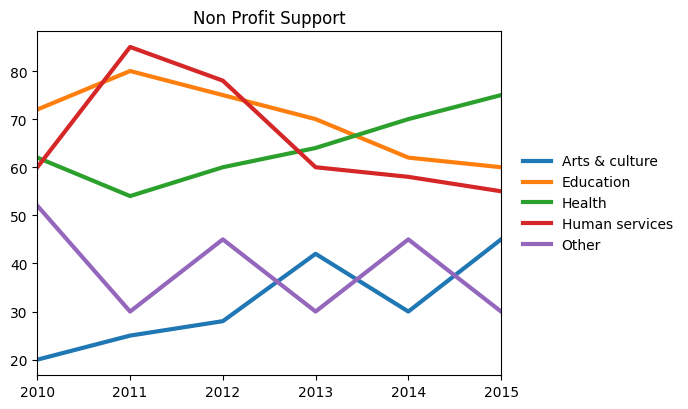

In [ ]:
import matplotlib.pyplot as plt


years = np.arange(2010, 2016)

arts_culture = [20, 25, 28, 42, 30, 45]
education  = [72, 80, 75, 70, 62, 60]
health = [62, 54, 60, 64, 70, 75]
human_srv  = [60, 85, 78, 60, 58, 55]
other     = [52, 30, 45, 30, 45, 30]

plt.figure(figsize=(7, 4.2))
plt.plot(years, arts_culture,label="Arts & culture", linewidth=3)
plt.plot(years, education, label="Education", linewidth=3)
plt.plot(years, health,label="Health", linewidth=3)
plt.plot(years, human_srv, label="Human services", linewidth=3)
plt.plot(years, other,label="Other", linewidth=3)

plt.title("Non Profit Support")
plt.xticks(years)
plt.xlim(2010, 2015)

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()

